# Exploration, nettoyage et fusion des donnees Agritech

Ce notebook documente la procedure d'exploration des donnees, de nettoyage, de transformation, d'encodage et de fusion pour repondre a la premiere partie de la mission.

Objectifs :
- comprendre les deux familles de datasets disponibles ;
- identifier les cles de jointure pertinentes ;
- nettoyer et standardiser les colonnes ;
- construire un dataset consolide exploitable pour l'entrainement ;
- preparer les transformations de features pour la modelisation ;
- produire une ACP interpretable sur le dataset agronomique `crop_yield.csv`.

## Plan

1. Chargement et cadrage des sources
2. Audit rapide des schemas, doublons et valeurs manquantes
3. Standardisation des cles geographiques et temporelles
4. Construction du dataset consolide
5. Controles qualite post-fusion
6. Preparation des transformations pour le modele
7. ACP sur le dataset agronomique complementaire
8. Synthese metier et technique

In [1]:
from pathlib import Path

import json

import re

import unicodedata



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from IPython.display import display

from sklearn.compose import ColumnTransformer

from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler



plt.style.use('ggplot')

pd.set_option('display.max_columns', 50)

pd.set_option('display.max_rows', 100)



ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]

ROOT = next((path for path in ROOT_CANDIDATES if (path / 'DATA').exists()), Path.cwd())

DATA_DIR = ROOT / 'DATA'

ARTIFACTS_DIR = ROOT / 'artifacts'

ARTIFACTS_DATA_DIR = ARTIFACTS_DIR / 'data'

ARTIFACTS_REPORTS_DIR = ARTIFACTS_DIR / 'reports'

ARTIFACTS_DATA_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_REPORTS_DIR.mkdir(parents=True, exist_ok=True)



ROOT


PosixPath('/app')

In [2]:
AREA_ALIASES = {
    'bolivia plurinational state of': 'bolivia',
    'cote divoire': 'cote d ivoire',
    'democratic republic of the congo': 'democratic republic of congo',
    'iran islamic republic of': 'iran',
    'lao peoples democratic republic': 'laos',
    'republic of moldova': 'moldova',
    'syrian arab republic': 'syria',
    'the former yugoslav republic of macedonia': 'north macedonia',
    'united kingdom of great britain and northern ireland': 'united kingdom',
    'united republic of tanzania': 'tanzania',
    'united states of america': 'united states',
    'venezuela bolivarian republic of': 'venezuela',
    'viet nam': 'vietnam',
}

def normalize_area_key(value: str) -> str:
    normalized = unicodedata.normalize('NFKD', str(value)).encode('ascii', 'ignore').decode('ascii')
    normalized = normalized.lower()
    normalized = re.sub(r'[^a-z0-9]+', ' ', normalized).strip()
    return AREA_ALIASES.get(normalized, normalized)

def prepare_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame.columns = [column.strip() for column in frame.columns]
    return frame

def describe_frame(name: str, frame: pd.DataFrame) -> dict:
    return {
        'dataset': name,
        'rows': int(frame.shape[0]),
        'columns': int(frame.shape[1]),
        'duplicate_rows': int(frame.duplicated().sum()),
        'missing_cells': int(frame.isna().sum().sum()),
    }

In [3]:
raw_frames = {
    'crop_yield_prediction': pd.read_csv(DATA_DIR / 'crop_yield.csv'),
    'historical_yield': pd.read_csv(DATA_DIR / 'yield.csv'),
    'rainfall': pd.read_csv(DATA_DIR / 'rainfall.csv'),
    'pesticides': pd.read_csv(DATA_DIR / 'pesticides.csv'),
    'temperature': pd.read_csv(DATA_DIR / 'temp.csv'),
}

summary_table = pd.DataFrame([describe_frame(name, frame) for name, frame in raw_frames.items()])
summary_table

,dataset,rows,columns,duplicate_rows,missing_cells
0,crop_yield_prediction,1000000,10,0,0
1,historical_yield,56717,12,0,0
2,rainfall,6727,3,0,774
3,pesticides,4349,7,0,0
4,temperature,71311,3,6958,2547


In [4]:
for name, frame in raw_frames.items():
    print(f'\n### {name}')
    display(frame.head(3))
    print(frame.dtypes)


### crop_yield_prediction


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443


Region                     object
Soil_Type                  object
Crop                       object
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition          object
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

### historical_yield


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260


Domain Code     object
Domain          object
Area Code        int64
Area            object
Element Code     int64
Element         object
Item Code        int64
Item            object
Year Code        int64
Year             int64
Unit            object
Value            int64
dtype: object

### rainfall


...

 Area                            object
Year                              int64
average_rain_fall_mm_per_year    object
dtype: object

### pesticides


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0


Domain      object
Area        object
Element     object
Item        object
Year         int64
Unit        object
Value      float64
dtype: object

### temperature


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67


year          int64
country      object
avg_temp    float64
dtype: object


## Strategie retenue

Le projet contient en pratique deux familles de donnees :

- `yield.csv` + `rainfall.csv` + `pesticides.csv` + `temp.csv` : ce bloc est exploitable pour construire le dataset consolide de prediction car il partage des dimensions geographiques et temporelles (`Area/country`, `Year/year`).
- `crop_yield.csv` : dataset agronomique complementaire tres volumineux, utile pour valider les facteurs explicatifs, illustrer les distributions et realiser une ACP orientee interpretabilite.

La cle de jointure retenue pour le dataset source de verite est donc :
- geographie normalisee via `area_key` ;
- annee via `Year`.

La culture (`Item`) reste la dimension cible du probleme de prediction / recommandation.

In [5]:
missing_ratio = pd.DataFrame({
    name: frame.isna().mean().sort_values(ascending=False).head(10)
    for name, frame in raw_frames.items()
}).fillna(0)
missing_ratio

,crop_yield_prediction,historical_yield,rainfall,pesticides,temperature
Area,0.0,0.0,0.000000,0.0,0.000000
Area,0.0,0.0,0.000000,0.0,0.000000
Area Code,0.0,0.0,0.000000,0.0,0.000000
Crop,0.0,0.0,0.000000,0.0,0.000000
Days_to_Harvest,0.0,0.0,0.000000,0.0,0.000000
Domain,0.0,0.0,0.000000,0.0,0.000000
Domain Code,0.0,0.0,0.000000,0.0,0.000000
Element,0.0,0.0,0.000000,0.0,0.000000
Element Code,0.0,0.0,0.000000,0.0,0.000000
Fertilizer_Used,0.0,0.0,0.000000,0.0,0.000000


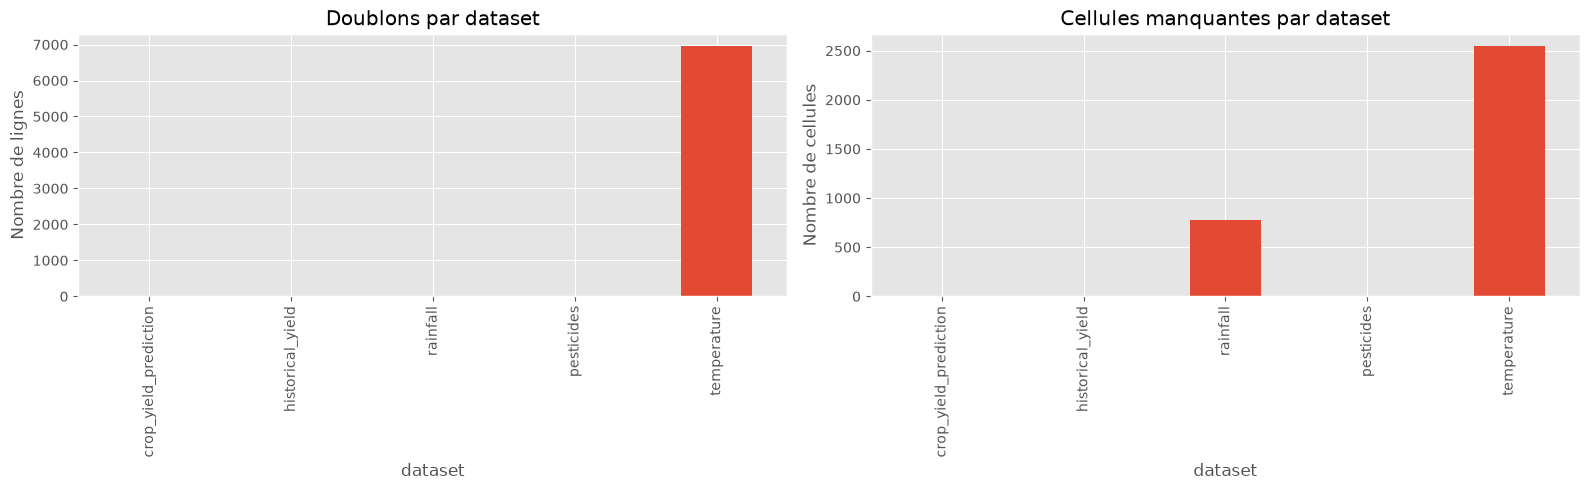

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
summary_table.set_index('dataset')['duplicate_rows'].plot(kind='bar', ax=axes[0], title='Doublons par dataset')
summary_table.set_index('dataset')['missing_cells'].plot(kind='bar', ax=axes[1], title='Cellules manquantes par dataset')
axes[0].set_ylabel('Nombre de lignes')
axes[1].set_ylabel('Nombre de cellules')
plt.tight_layout()

In [7]:
historical_yield = prepare_frame(raw_frames['historical_yield']).rename(columns={'Value': 'hg_ha_yield'})
historical_yield = historical_yield[['Area', 'Item', 'Year', 'hg_ha_yield']].copy()
historical_yield['area_key'] = historical_yield['Area'].map(normalize_area_key)

rainfall = prepare_frame(raw_frames['rainfall'])
rainfall['area_key'] = rainfall['Area'].map(normalize_area_key)
rainfall['average_rain_fall_mm_per_year'] = pd.to_numeric(rainfall['average_rain_fall_mm_per_year'], errors='coerce')
rainfall = rainfall[['area_key', 'Year', 'average_rain_fall_mm_per_year']]

pesticides = prepare_frame(raw_frames['pesticides']).rename(columns={'Value': 'pesticides_tonnes'})
pesticides['area_key'] = pesticides['Area'].map(normalize_area_key)
pesticides['pesticides_tonnes'] = pd.to_numeric(pesticides['pesticides_tonnes'], errors='coerce')
pesticides = pesticides[['area_key', 'Year', 'pesticides_tonnes']]

temperature = prepare_frame(raw_frames['temperature']).rename(columns={'year': 'Year', 'country': 'Area'})
temperature['area_key'] = temperature['Area'].map(normalize_area_key)
temperature['avg_temp'] = pd.to_numeric(temperature['avg_temp'], errors='coerce')
temperature = temperature[['area_key', 'Year', 'avg_temp']]

crop_yield = prepare_frame(raw_frames['crop_yield_prediction']).copy()
crop_yield['Fertilizer_Used'] = crop_yield['Fertilizer_Used'].astype(int)
crop_yield['Irrigation_Used'] = crop_yield['Irrigation_Used'].astype(int)

display(historical_yield.head())
display(crop_yield.head())

,Area,Item,Year,hg_ha_yield,area_key
0,Afghanistan,Maize,1961,14000,afghanistan
1,Afghanistan,Maize,1962,14000,afghanistan
2,Afghanistan,Maize,1963,14260,afghanistan
3,Afghanistan,Maize,1964,14257,afghanistan
4,Afghanistan,Maize,1965,14400,afghanistan


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,0,1,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,0,0,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,7.248251


In [8]:
coverage = {
    'yield_area_year': set(historical_yield[['area_key', 'Year']].itertuples(index=False, name=None)),
    'rainfall_area_year': set(rainfall[['area_key', 'Year']].itertuples(index=False, name=None)),
    'pesticides_area_year': set(pesticides[['area_key', 'Year']].itertuples(index=False, name=None)),
    'temperature_area_year': set(temperature[['area_key', 'Year']].itertuples(index=False, name=None)),
}

coverage_report = pd.DataFrame({
    'pairs': [len(values) for values in coverage.values()],
}, index=list(coverage.keys()))

coverage_report['coverage_vs_yield'] = [
    len(coverage['yield_area_year'] & coverage[key]) / len(coverage['yield_area_year'])
    for key in coverage_report.index
]
coverage_report

,pairs,coverage_vs_yield
yield_area_year,10572,1.000000
rainfall_area_year,6727,0.480609
pesticides_area_year,4349,0.408437
temperature_area_year,28514,0.577090


In [9]:
merged = historical_yield.merge(rainfall, on=['area_key', 'Year'], how='left')
merged = merged.merge(pesticides, on=['area_key', 'Year'], how='left')
merged = merged.merge(temperature, on=['area_key', 'Year'], how='left')

merged = merged[merged['Year'] >= 1990].copy()
required_columns = ['hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
master_dataset = merged.dropna(subset=required_columns).drop(columns=['area_key'])
master_dataset = master_dataset.sort_values(['Area', 'Item', 'Year']).reset_index(drop=True)

merge_report = {
    'rows_after_merge': int(len(master_dataset)),
    'year_min': int(master_dataset['Year'].min()),
    'year_max': int(master_dataset['Year'].max()),
    'areas': int(master_dataset['Area'].nunique()),
    'items': int(master_dataset['Item'].nunique()),
    'duplicates_after_merge': int(master_dataset.duplicated().sum()),
    'missing_share_after_drop': {
        column: float(merged[column].isna().mean())
        for column in required_columns
    },
}

master_dataset.to_csv(ARTIFACTS_DATA_DIR / 'consolidated_yield.csv', index=False)
(ARTIFACTS_DATA_DIR / 'merge_report.json').write_text(json.dumps(merge_report, indent=2), encoding='utf-8')

display(master_dataset.head())
merge_report

,Area,Item,Year,hg_ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Maize,1991,29068,1485.0,121.0,15.36
2,Albania,Maize,1992,24876,1485.0,121.0,16.06
3,Albania,Maize,1993,24185,1485.0,121.0,16.05
4,Albania,Maize,1994,25848,1485.0,201.0,16.96


{'rows_after_merge': 38382,
 'year_min': 1990,
 'year_max': 2013,
 'areas': 110,
 'items': 10,
 'duplicates_after_merge': 4200,
 'missing_share_after_drop': {'hg_ha_yield': 0.0,
  'average_rain_fall_mm_per_year': 0.12450773447591443,
  'pesticides_tonnes': 0.21202860653413566,
  'avg_temp': 0.185958224378564}}

In [10]:
quality_checks = pd.Series({
    'rows': len(master_dataset),
    'columns': master_dataset.shape[1],
    'areas': master_dataset['Area'].nunique(),
    'crops': master_dataset['Item'].nunique(),
    'duplicates': master_dataset.duplicated().sum(),
    'missing_cells': master_dataset.isna().sum().sum(),
})
quality_checks

rows             38382
columns              7
areas              110
crops               10
duplicates        4200
missing_cells        0
dtype: int64

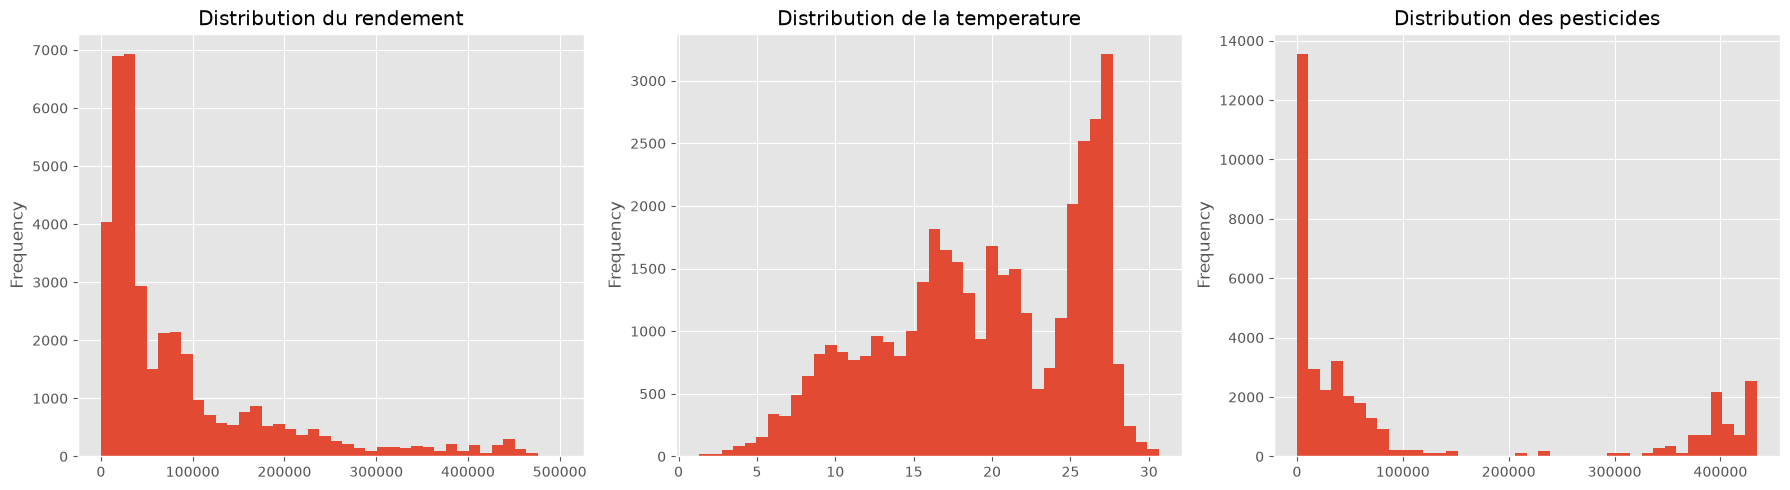

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
master_dataset['hg_ha_yield'].plot(kind='hist', bins=40, ax=axes[0], title='Distribution du rendement')
master_dataset['avg_temp'].plot(kind='hist', bins=40, ax=axes[1], title='Distribution de la temperature')
master_dataset['pesticides_tonnes'].plot(kind='hist', bins=40, ax=axes[2], title='Distribution des pesticides')
plt.tight_layout()

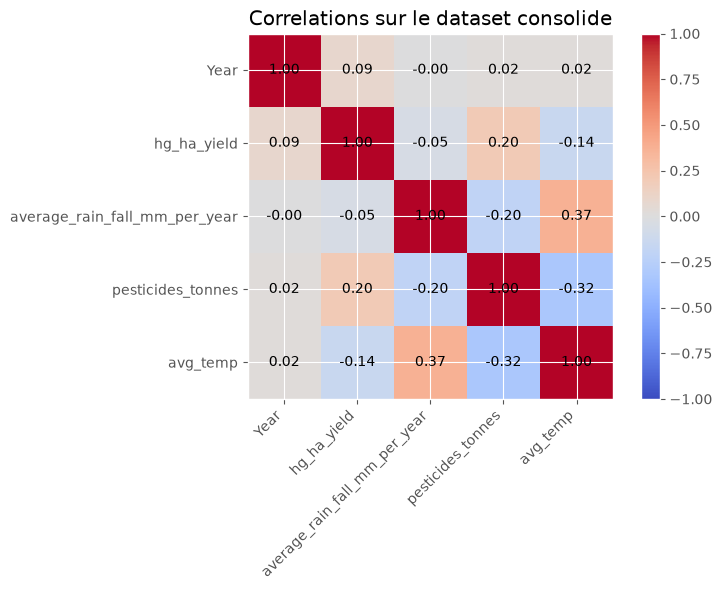

In [12]:
numeric_columns = ['Year', 'hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
corr = master_dataset[numeric_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
heatmap = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
for row in range(corr.shape[0]):
    for col in range(corr.shape[1]):
        ax.text(col, row, f'{corr.iloc[row, col]:.2f}', ha='center', va='center', color='black')
fig.colorbar(heatmap, ax=ax)
ax.set_title('Correlations sur le dataset consolide')
plt.tight_layout()

## Preparation des transformations pour la modelisation

Le dataset consolide melange :
- des variables categorielles (`Area`, `Item`) ;
- des variables numeriques (`Year`, `average_rain_fall_mm_per_year`, `pesticides_tonnes`, `avg_temp`).

La preparation classique pour un modele de regression consiste a :
- encoder les categories en one-hot encoding ;
- standardiser les variables numeriques ;
- conserver le tout dans un pipeline reproductible.

In [13]:
feature_columns = ['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
categorical_features = ['Area', 'Item']
numeric_features = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numeric', StandardScaler(), numeric_features),
    ]
)

encoded_matrix = preprocessor.fit_transform(master_dataset[feature_columns])
encoded_shape = encoded_matrix.shape
feature_names = preprocessor.get_feature_names_out()

encoded_shape, feature_names[:15]

((38382, 124),
 array(['categorical__Area_Albania', 'categorical__Area_Algeria',
        'categorical__Area_Angola', 'categorical__Area_Argentina',
        'categorical__Area_Armenia', 'categorical__Area_Australia',
        'categorical__Area_Austria', 'categorical__Area_Azerbaijan',
        'categorical__Area_Bahamas', 'categorical__Area_Bahrain',
        'categorical__Area_Bangladesh', 'categorical__Area_Belarus',
        'categorical__Area_Belgium',
        'categorical__Area_Bolivia (Plurinational State of)',
        'categorical__Area_Botswana'], dtype=object))

## ACP sur le dataset agronomique `crop_yield.csv`

Ce dataset n'est pas la base de jointure principale, mais il sert a expliciter les facteurs agronomiques dominants. Comme il contient 1 000 000 de lignes, on travaille sur un echantillon aleatoire reproductible pour limiter le cout de calcul.

In [14]:
sample_size = min(len(crop_yield), 50000)
crop_sample = crop_yield.sample(n=sample_size, random_state=42).copy()

numeric_crop_features = [
    'Rainfall_mm',
    'Temperature_Celsius',
    'Fertilizer_Used',
    'Irrigation_Used',
    'Days_to_Harvest',
    'Yield_tons_per_hectare',
]
categorical_crop_features = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

crop_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_crop_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_crop_features),
    ]
)

pca_pipeline = Pipeline(
    steps=[
        ('preprocessor', crop_preprocessor),
        ('pca', PCA(n_components=2, random_state=42)),
    ]
)

pca_pipeline.fit(crop_sample)
explained_variance_ratio = pca_pipeline.named_steps['pca'].explained_variance_ratio_
crop_feature_names = pca_pipeline.named_steps['preprocessor'].get_feature_names_out()
components = pca_pipeline.named_steps['pca'].components_

pd.Series(explained_variance_ratio, index=['PC1', 'PC2'])

PC1    0.215993
PC2    0.110773
dtype: float64

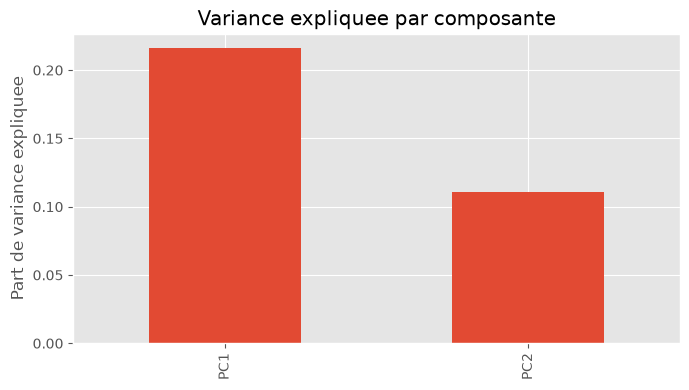

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
pd.Series(explained_variance_ratio, index=['PC1', 'PC2']).plot(kind='bar', ax=ax, title='Variance expliquee par composante')
ax.set_ylabel('Part de variance expliquee')
plt.tight_layout()

In [16]:
top_features = []
for index, component in enumerate(components, start=1):
    top_indices = np.argsort(np.abs(component))[-10:][::-1]
    top_features.append(
        pd.DataFrame({
            'component': f'PC{index}',
            'feature': crop_feature_names[top_indices],
            'loading': component[top_indices],
        })
    )

pca_top_features = pd.concat(top_features, ignore_index=True)
pca_top_features

,component,feature,loading
0,PC1,numeric__Yield_tons_per_hectare,0.705991
1,PC1,numeric__Rainfall_mm,0.563779
2,PC1,numeric__Fertilizer_Used,0.327616
3,PC1,numeric__Irrigation_Used,0.269021
4,PC1,numeric__Temperature_Celsius,0.062526
5,PC1,numeric__Days_to_Harvest,-0.009444
6,PC1,categorical__Region_West,-0.002923
7,PC1,categorical__Soil_Type_Chalky,0.001953
8,PC1,categorical__Soil_Type_Loam,-0.001819
9,PC1,categorical__Crop_Barley,-0.001725


In [17]:
pca_summary = {
    'sample_size': int(sample_size),
    'explained_variance_ratio': [float(value) for value in explained_variance_ratio],
    'top_features': {
        component: group[['feature', 'loading']].to_dict(orient='records')
        for component, group in pca_top_features.groupby('component')
    },
}

(ARTIFACTS_REPORTS_DIR / 'crop_factor_pca_summary.json').write_text(json.dumps(pca_summary, indent=2), encoding='utf-8')
pca_top_features.to_csv(ARTIFACTS_REPORTS_DIR / 'crop_factor_pca_loadings.csv', index=False)
pca_summary

{'sample_size': 50000,
 'explained_variance_ratio': [0.21599285317973743, 0.11077259179575062],
 'top_features': {'PC1': [{'feature': 'numeric__Yield_tons_per_hectare',
    'loading': 0.7059905226409114},
   {'feature': 'numeric__Rainfall_mm', 'loading': 0.5637785663787106},
   {'feature': 'numeric__Fertilizer_Used', 'loading': 0.3276159066680629},
   {'feature': 'numeric__Irrigation_Used', 'loading': 0.2690212949974211},
   {'feature': 'numeric__Temperature_Celsius', 'loading': 0.06252556887192517},
   {'feature': 'numeric__Days_to_Harvest', 'loading': -0.00944442684176138},
   {'feature': 'categorical__Region_West', 'loading': -0.002922718586187558},
   {'feature': 'categorical__Soil_Type_Chalky',
    'loading': 0.0019530773083333878},
   {'feature': 'categorical__Soil_Type_Loam',
    'loading': -0.001818797224436992},
   {'feature': 'categorical__Crop_Barley', 'loading': -0.0017248324355149623}],
  'PC2': [{'feature': 'numeric__Temperature_Celsius',
    'loading': 0.6761978888238268

## Synthese des decisions de preparation

- Le dataset historique de rendement (`yield.csv`) sert de table de reference pour la cible.
- Les variables exogenes pluie, pesticides et temperature sont rattachees par `Area` et `Year` apres normalisation textuelle de la geographie.
- Les lignes anterieures a 1990 sont retirees pour rester sur l'intersection utile avec les autres sources.
- Les lignes encore inexploitables apres fusion sont exclues uniquement si une variable critique est manquante.
- Les variables categorielles sont encodees en one-hot ; les numeriques sont standardisees.
- L'ACP sur `crop_yield.csv` permet d'expliquer quelles dimensions agronomiques portent le plus de variance dans le dataset complementaire.

Artefacts produits par ce notebook :
- `artifacts/data/consolidated_yield.csv`
- `artifacts/data/merge_report.json`
- `artifacts/reports/crop_factor_pca_summary.json`
- `artifacts/reports/crop_factor_pca_loadings.csv`